Study pairwise unit cross-correlation around ripples

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import regions as rg
import xarray as xr
import itertools
import concurrent.futures
import os
import matplotlib.pyplot as plt
import scipy as sp
import ISRUtilities as isru
import pathlib
froot = pathlib.Path().cwd().parent / 'Figures'

Useful code to test PETH with sliding windows

In [27]:
# ground truth test function
def slowPETH(samples,events,t,win):
    # t: window centers (s), win: bin size (s)
    mat = np.zeros((len(events),len(t)))
    for i, e in enumerate(events):
        for j, center in enumerate(t):
            valid = ((np.array(samples)-e) > center-win/2) & ((np.array(samples)-e) <= center+win/2)
            mat[i,j] = sum(valid)
    return mat

True


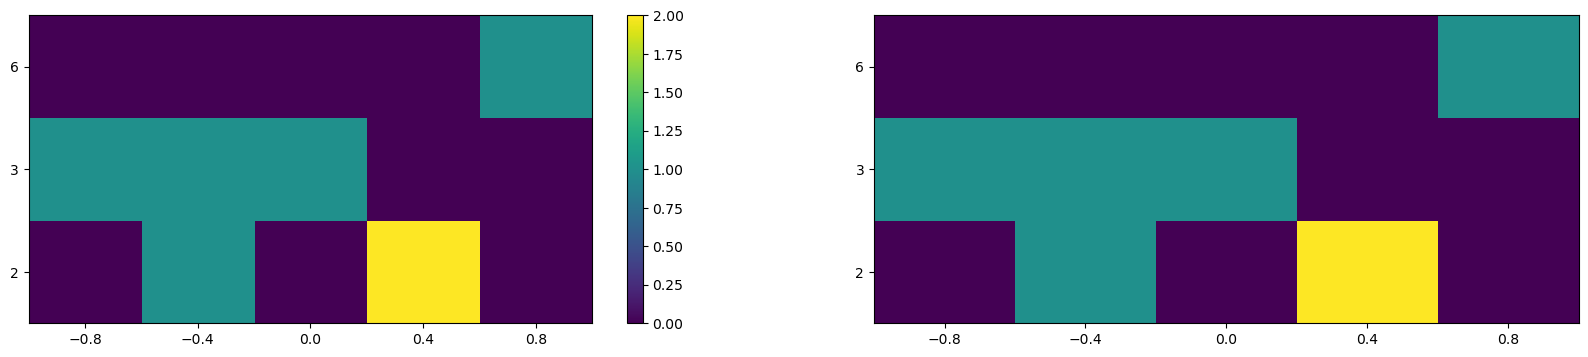

In [91]:
# test PETH
s = np.array([1.1,1.4,2.2,3,3,4.9,5.1,5.2,7,9])
s = np.random.uniform(low=0,high=8,size=15)
e = [2,3,6]
g = np.random.randint(0,2,len(s))
#g = np.ones(len(s))
#g[0] = 0
lim = [-1,1]
nb = 5
p, t, _ = fma.analysis.PETH(s,e,limits=lim,n_bins=nb,step=1,groups=g)
selected_group = 1
p = p[:,:,selected_group]
p0 = slowPETH(s[g==selected_group],e,t,(lim[1]-lim[0])/nb)
# plot
_, axs = plt.subplots(1,2,figsize=(20,4))
im0 = fma.plotting.plotColorMap(p0,x=t,ax=axs[0])
im1 = fma.plotting.plotColorMap(p,x=t,ax=axs[1])
plt.colorbar(im0)
axs[0].set_xticks(t), axs[1].set_xticks(t), axs[0].set_yticks(np.arange(len(e)),labels=e), axs[1].set_yticks(np.arange(len(e)),labels=e)
plt.subplots_adjust()
print(np.all(p==p0))

test on example session

In [2]:
def _laggedSpikeCrossCorr(session,regs=None,shift=-1,pairs=None):
    # compute lagged cross-region pairwise unit correlation around ripple-peak times as (shuffle, region, lag) XArray
    # 'shuffle' coordinate is False iff corresponding data values are real

    R = rg.data.Regions(session,states='sws',events=['InfraSlowRhythm/slownr','InfraSlowRhythm/slowavalnr','ripples'])
    regs = R.ids if regs is None else np.array(regs)
    reg_pair_idx = list(itertools.permutations(range(len(regs)),2)) if pairs is None else pairs
    reg_pairs = [f'{regs[rp[0]]}-{regs[rp[1]]}' for rp in reg_pair_idx]
    is_reg = np.isin(regs,R.ids) # is_reg[i] is True if regs[i] is in R.ids
    unit_range = {regs[i]: [R.spikes(regs[i])[:,1].min(),R.spikes(regs[i])[:,1].max()] if r else None for i, r in enumerate(is_reg)}
    rip_time = R.eventInfo('ripples')[:,2]

    #isr = R.eventInfo('slownr')
    #on = R.eventInfo('slowavalnr')
    #_, is_ok = fma.general.restrict(on[:,0]-.0001,isr,s_ind=True)
    #off_on = fma.general.restrict(on[is_ok,0],R.eventIntervals('sws')).ravel() # restrict in nREM to shuffle transitions
    #_, is_ok = fma.general.restrict(on[:,1]+.0001,isr,s_ind=True)
    #on_off = on[is_ok,1]

    # 1. count spikes in overlapping windows around event times
    win_size = 0.2
    n_strides = 7 # time resolution will be win_size / n_strides
    n_bins = 7
    limits = [-n_bins*win_size/2, n_bins*win_size/2] # could be [-0.7,0.7]
    n_times = (n_bins-1) * n_strides + 1
    counts = {}
    for j, r in enumerate(regs[is_reg]):
        m, times, _ = fma.analysis.PETH(R.spikes(r)[:,0],rip_time,limits=limits,n_bins=n_bins,step=n_strides,groups=R.spikes(r)[:,1],g_range=unit_range[r],fast=True) # (n_ripples, n_lags, n_units)
        m = sp.stats.rankdata(m,axis=1) # rank along transitions
        counts[r] = m - m.mean(axis=1,keepdims=True) # center ranks

    # 2. average pairwise cross correlation, observed and shifted
    spearman = np.full((2,len(reg_pairs),n_times),np.nan)
    for i, rp in enumerate(reg_pair_idx):
        if is_reg[rp[0]] and is_reg[rp[1]]:
            # prepare observed and shifted (along events) spike counts
            ref = np.tile(counts[regs[rp[0]]][:,n_times//2,:],(2,1,1)) # (2, n_ripples, n_units1), at lag 0 s
            lagged = np.stack([counts[regs[rp[1]]], np.roll(counts[regs[rp[1]]],shift=shift,axis=0)], axis=0) # (2, n_ripples, n_lags, n_units2)

            num = np.einsum('pnm,pnlk->pmlk',ref,lagged) # numerator: covariance across events
            ref_norm = np.linalg.norm(ref,axis=1) # (2, n_units1)
            lag_norm = np.linalg.norm(lagged,axis=1) # (2, n_lags, n_units2)

            with np.errstate(invalid='ignore'): # suppress 0 / 0 warning
                spear = num / (ref_norm[:,:,None,None] * lag_norm[:,None,:,:]) # spear[p,i,l,j] is the Spearman correlation between ref_count[:,i] and counts[reg2][:,l,j] for real / shuffle
            # average across unit pairs
            spearman[:,i,:] = np.nanmean(spear,axis=(1,3))

    xdata = xr.DataArray(spearman,dims=('shuffle','region','lag'),coords={'shuffle': [False,True],'region': reg_pairs,'lag': times})

    return xdata

In [2]:
def _transitionCorr(session,regs=None,pairs=None,n_shuffle=0,verbose=False):
    # compute lagged cross-region pairwise unit correlation around ripple-peak times as (shuffle, region, lag) XArray
    # 'shuffle' coordinate is False iff corresponding data values are real

    R = rg.data.Regions(session,states='sws',events=['InfraSlowRhythm/slownr','InfraSlowRhythm/slowavalnr','ripples'])
    regs = R.ids if regs is None else np.array(regs)
    reg_pair_idx = list(itertools.permutations(range(len(regs)),2)) if pairs is None else pairs
    reg_pairs = [f'{regs[rp[0]]}-{regs[rp[1]]}' for rp in reg_pair_idx]
    is_reg = np.isin(regs,R.ids) # is_reg[i] is True if regs[i] is in R.ids
    unit_range = {regs[i]: [R.spikes(regs[i])[:,1].min(),R.spikes(regs[i])[:,1].max()] if r else None for i, r in enumerate(is_reg)}

    # shuffle ripple times
    rip_time = R.eventInfo('ripples')[:,2]
    #isr = R.eventInfo('slownr')
    #on = R.eventInfo('slowavalnr')
    #_, is_ok = fma.general.restrict(on[:,0]-.0001,isr,s_ind=True)
    #off_on = fma.general.restrict(on[is_ok,0],R.eventIntervals('sws')).ravel() # restrict in nREM to shuffle transitions
    #_, is_ok = fma.general.restrict(on[:,1]+.0001,isr,s_ind=True)
    #on_off = on[is_ok,1]
    shuffled_rip_time = np.zeros((len(rip_time),n_shuffle+1)) # each column is a shuffle, first is observed
    shuffled_rip_time[:,0] = rip_time
    for i in range(n_shuffle):
        shuffled_rip_time[:,i+1] = fma.general.shuffleEvents(rip_time,intervals=R.eventIntervals('sws'))

    # analysis parameters
    win_size = 0.2
    n_strides = 7 # time resolution will be win_size / n_strides
    n_wins = 7
    limits = [-n_wins*win_size/2, n_wins*win_size/2] # could be [-0.7,0.7]
    n_times = (n_wins-1) * n_strides + 1
    counts = {}
    spearman = np.full((n_shuffle+1,len(reg_pairs),n_times),np.nan)
    chunk_size = 100
    for k in range(0,n_shuffle+1,chunk_size):
        verbose and print(f'chunk: {k}')

        # concatenate chunk
        this_times = shuffled_rip_time[:,k:k+chunk_size].ravel('F')
        this_chunk_size = len(this_times) // shuffled_rip_time.shape[0]

        # 1. count spikes in overlapping windows around event times, only for regions in R
        for j, r in enumerate(regs[is_reg]):
            m, times, _ = fma.analysis.PETH(R.spikes(r)[:,0],this_times,limits=limits,n_bins=n_wins,step=n_strides,groups=R.spikes(r)[:,1],g_range=unit_range[r],fast=True)
            counts[r] = m.reshape((this_chunk_size,len(rip_time),n_times,int(unit_range[r][1]-unit_range[r][0])+1)) # (chunk_size, n_ripples, n_lags, n_units)
            counts[r] = sp.stats.rankdata(counts[r],axis=1) # rank along transitions
            counts[r] = counts[r] - counts[r].mean(axis=1,keepdims=True) # center ranks
        verbose and print(f'done peth')

        # 2. average pairwise cross correlation
        for i, rp in enumerate(reg_pair_idx):
            if is_reg[rp[0]] and is_reg[rp[1]]:

                ref_centered = counts[regs[rp[0]]][:,:,n_times//2,:] # (chunk_size, n_transitions, n_units1), at lag 0 s
                lagged_centered = counts[regs[rp[1]]] # (chunk_size, n_transitions, n_lags, n_units2)

                num = np.einsum('pnm,pnlk->pmlk',ref_centered,lagged_centered) # numerator: covariance across transitions
                ref_norm = np.linalg.norm(ref_centered,axis=1) # (chunk_size, n_units1,)
                lag_norm = np.linalg.norm(lagged_centered,axis=1) # (chunk_size, n_lags, n_units2)

                with np.errstate(invalid='ignore'): # suppress 0 / 0 warning
                    spear = num / (ref_norm[:,:,None,None] * lag_norm[:,None,:,:]) # spear[p,i,l,j] is the Spearman correlation between ref_count[:,i] and counts[reg2][:,l,j] for shuffle p
                # average across unit pairs
                spearman[k:k+this_chunk_size,i,:] = np.nanmean(spear,axis=(1,3))
        verbose and print(f'done spear')

    xdata = xr.DataArray(spearman,dims=('shuffle','region','lag'),coords={'shuffle': [False] + [True]*n_shuffle,'region': reg_pairs,'lag': times})

    return xdata

In [3]:
regs = ['hpc','nr','pfc']
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_units.batch'

In [4]:
# test one session
session = fma.data.readBatchFile(batch_file)[0][19]
print(f'session: {session}')
xdata = _laggedSpikeCrossCorr(session,regs,pairs=[[0,1]])

session: /mnt/hubel-data-140/karadoc/Rat004_20240306/Rat004_20240306.xml


In [ ]:
# interpretation: reg1 pop vector at transition correlated with reg2's delayed
fig, axs = fma.plotting.makeFigure('Lagged pairwise correlation around ripples',[1,6],[35,8])
for i, r in enumerate(xdata['region']):
    reg_data = xdata.sel(region=r)
    fma.plotting.semPlot(xdata['lag'],reg_data.sel(shuffle=True),zscore=False,color='#AAAAAA',label=str(r.item().upper()),ax=axs[i])
    axs[i].plot(xdata['lag'],reg_data.sel(shuffle=False),color=isru.paperColors(i),label=str(r.item().upper()))
    axs[i].set_xlabel('t from ripple (s)'), axs[i].set_title(r.values)
    axs[i].axvline(0,ls='--',color='k')
axs[0].set_ylabel('corr');

run batch

In [11]:
#xdata = fma.data.runBatch(batch_file,_transitionCorr,[[regs]],{'n_shuffle': 1000},ignore_args=True,parallel=12)
xdata = fma.data.runBatch(batch_file,_laggedSpikeCrossCorr,[[regs]],{'shift': -2},ignore_args=True,parallel=40)


Starting Batch, 2026-06-05 16:45:18.678448 

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230815/Rat002_20230815.xml (34)
/mnt/hubel-data-148/blinky/Training/Rat002_20230815/Rat002_20230815.ripples not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230816/Rat002_20230816.xml (35)
/mnt/hubel-data-148/blinky/Training/Rat002_20230816/Rat002_20230816.ripples not found.
Traceback:
Error 

In [13]:
# concatenate data
data_cat = xr.concat([d for d in xdata if d is not None],dim='session')
# grand-average statistical test MISSING shuffle=True !!!
pval = {r.item(): fma.analysis.maxStatisticTest(data_cat.sel(region=r,shuffle=False),data_cat.sel(region=r).transpose('session','lag',...)) for r in data_cat.region}

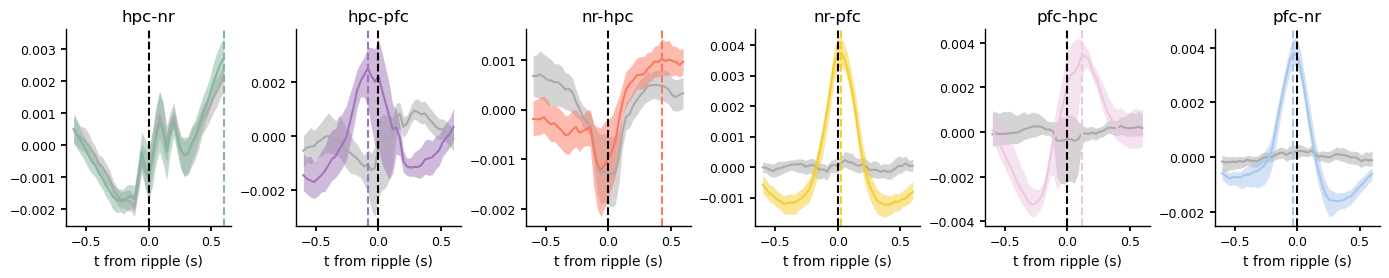

In [14]:
# Figure 2?
fig, axs = fma.plotting.makeFigure('',[1,6],size=[35,7])
for i, r in enumerate(data_cat['region'].values):
    reg_data = data_cat.sel(region=r)
    fma.plotting.semPlot(data_cat['lag'],reg_data.sel(shuffle=True),zscore=False,color='#AAAAAA',label=r.upper(),ax=axs[i])
    fma.plotting.semPlot(data_cat['lag'],reg_data.sel(shuffle=False),zscore=False,color=isru.paperColors(i),label=r.upper(),ax=axs[i])
    peak_time = np.argmax(reg_data.sel(shuffle=False).mean('session').data)
    axs[i].axvline(reg_data.lag[peak_time],ls='--',color=isru.paperColors(i)),
    axs[i].axvline(0,ls='--',color='k'), axs[i].set_xlabel('t from ripple (s)'), axs[i].set_title(r)
    # statistical significance
    fma.plotting.pHorzLine(pval[r],data_cat['lag'],color=isru.paperColors(i),ax=axs[i])
#fma.plotting.saveFigure(fig,froot/'Figure3/Fig3g_fr_rip',['svg','png'])

Pspyke: su finestre temporali si pu﷿﷿﷿﷿﷿﷿ valutare nwueon-level correlazioni, magari intporno a ripples

Come H0 potrei guardare se momenti di burst in HPC senza ripples sono risultati simili